# ITM 454 - Natural Language Processing
## Sentiment Analysis using Logistic Regression

---

### 1. Import Required Libraries and Download Data

In [25]:
import nltk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Download required NLTK data
nltk.download('movie_reviews')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/soryapheakly/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/soryapheakly/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/soryapheakly/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

### 2. Load and Explore the Dataset

In [26]:
from nltk.corpus import movie_reviews
import random

# Load movie reviews dataset
print("Loading NLTK Movie Reviews Dataset...")
print("=" * 40)

# Get all file ids and their categories
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
# equivalent to
# documents = []
#     for category in movie_reviews.categories():
#         for fileid in movie_reviews.fileids(category):
#             documents.append((list(movie_reviews.words(fileid)), category))

# Shuffle the documents for better training
random.seed(94)
random.shuffle(documents)

print(f"Total number of reviews: {len(documents)}")
print(f"Categories: {movie_reviews.categories()}")
print(f"Number of positive reviews: {len(movie_reviews.fileids('pos'))}")
print(f"Number of negative reviews: {len(movie_reviews.fileids('neg'))}")

Loading NLTK Movie Reviews Dataset...
Total number of reviews: 2000
Categories: ['neg', 'pos']
Number of positive reviews: 1000
Number of negative reviews: 1000


In [27]:
print(f"Sample document format: {documents[0]}")
# documents are a list of tuple (word_list, category)
print(f"Word List for doc 0: {documents[0][0]}")
print(f"Category for doc 0: {documents[0][1]}")

# Convert to text format for easier processing
texts = [' '.join(words) for words, category in documents]
labels = [category for words, category in documents]

print(f"\nDataset shape: {len(texts)} reviews")
print(f"Label distribution: {Counter(labels)}")

Sample document format: (['for', '"', 'original', 'sin', ',', '"', 'the', 'road', 'to', 'the', 'screen', 'has', 'been', 'rocky', '.', 'initially', 'slated', 'for', 'release', 'last', 'november', ',', 'the', 'film', 'was', 'bumped', 'twice', ',', 'finally', 'landing', 'in', 'the', 'dog', 'days', 'of', 'summer', '2001', '.', 'advance', 'screenings', 'of', 'the', 'film', 'were', 'denied', 'to', 'all', 'but', 'a', 'few', 'critics', ',', 'generally', 'a', 'sign', 'that', 'the', 'studio', 'realizes', 'it', 'has', 'a', 'dud', 'on', 'its', 'hands', '.', 'so', 'is', '"', 'original', 'sin', '"', 'really', 'all', 'that', 'bad', '?', 'yes', 'it', 'is', ',', 'but', 'the', 'melodrama', 'does', 'offer', 'some', 'rewards', '.', 'the', 'location', 'settings', 'are', 'gorgeous', 'and', 'there', 'is', 'a', 'healthy', 'sprinkling', 'of', 't', '&', 'a', '(', 'with', 'angelina', 'jolie', 'providing', 'the', '"', 't', '"', 'and', 'antonio', 'banderas', 'the', '"', 'a', '"', ')', '.', 'more', 'importantly', '

In [28]:
# Display some sample reviews
print("Sample Reviews:")
print("=" * 50)

for i in range(3):
    print(f"\nReview {i+1} - Label: {labels[i].upper()}")
    print(f"{texts[i][:300]}...")
    print("-" * 50)

Sample Reviews:

Review 1 - Label: NEG
for " original sin , " the road to the screen has been rocky . initially slated for release last november , the film was bumped twice , finally landing in the dog days of summer 2001 . advance screenings of the film were denied to all but a few critics , generally a sign that the studio realizes it ...
--------------------------------------------------

Review 2 - Label: NEG
" battlefield earth " is the best comedy of the year . it has to be . the other prospect is just too horrifying to consider . bad movie syndrome struck me again , so after witnessing how much " battlefield earth " has been proclaimed a train wreck in both critical and popular circles , i felt the ma...
--------------------------------------------------

Review 3 - Label: POS
your friends and neighbors is a rather bizarre film about 6 people , who hop in and out of bed with each other . written and directed by neil labute , who ' s first film , " in the company of men " was sim

### 3. Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

# Split the data BEFORE preprocessing
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels  # Why stratify? = try to balance the label equally = cuz if not it'll be biased and affect the model
)

print(f"Training set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")
print(f"Training label distribution: {Counter(y_train)}")
print(f"Test label distribution: {Counter(y_test)}")

Training set size: 1600
Test set size: 400
Training label distribution: Counter({'pos': 800, 'neg': 800})
Test label distribution: Counter({'neg': 200, 'pos': 200})


### 4. Data Preprocessing
Text preprocessing tailored for sentiment analysis

In [30]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

def preprocess_text(text):    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text)
    
    # Remove numbers but keep some punctuation for sentiment
    text = re.sub(r'\d+', '', text)
    
    # Remove most special characters but keep basic punctuation since it's a part of sentiment features to express emotions
    text = re.sub(r'[^a-zA-Z\s!?.]', '', text)
    
    # Tokenize
    tokens = word_tokenize(text)

    # POS tagging right after tokenizaion 
    pos_tags = pos_tag(tokens)
    
    # Remove stopwords (but keep some sentiment-bearing words)
    stop_words = set(stopwords.words('english'))

    # Remove negation words from stopwords as they're important for sentiment
    negation_words = {'not', 'never', 'neither', 'nobody', 'nothing', 'nowhere', 'none'}
    stop_words = stop_words - negation_words
    
    tokens = [token for token in tokens if token not in stop_words and len(token) > 2]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    sent_pos = {'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS'}

    processed_tokens = []

    for token, pos in pos_tags: 
        if token not in stop_words and len(token) > 2: 
            lemmatized_token = lemmatizer.lemmatize(token)

            if pos in sent_pos: 
                processed_tokens.append(f"{lemmatized_token}_{pos}")
            else: 
                processed_tokens.append(lemmatized_token)
    
    return ' '.join(processed_tokens)

# Preprocess training and test data separately
print("Preprocessing training data...")
X_train_processed = [preprocess_text(text) for text in X_train_text]

print("Preprocessing test data...")
X_test_processed = [preprocess_text(text) for text in X_test_text]

print("\nBefore preprocessing (sample):")
print(X_train_text[0][:100] + "...") # print the first 100 chars of train_text[0]
print("\nAfter preprocessing (sample):")
print(X_train_processed[0][:100] + "...")

Preprocessing training data...
Preprocessing test data...

Before preprocessing (sample):
bruce willis and sixth sense director m . night shyamalan re - team to tell the story of david dunne...

After preprocessing (sample):
bruce willis sixth_JJ sense director night shyamalan team tell story david_JJ dunne willis stadium s...


### 5. Feature Extraction
Using TF-IDF for vectorization with parameters optimized for sentiment analysis

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization with parameters tuned for sentiment analysis
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Increase features for better sentiment capture
    ngram_range=(1, 2),       # Include both unigrams and bigrams, why?
    min_df=5,              
    max_df=0.8,      
)


# Fit ONLY on training data, then transform both train and test
X_train = tfidf_vectorizer.fit_transform(X_train_processed)
X_test = tfidf_vectorizer.transform(X_test_processed)

### 6. Model Training
Training Logistic Regression classifier for sentiment analysis

In [32]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression classifier
print("\nTraining Logistic Regression classifier...")
classifier = LogisticRegression(
    random_state=42,
    max_iter=1000,        # Increase iterations for convergence
    C=1.0                 # Regularization strength
)

classifier.fit(X_train, y_train)

print("Training completed!")
print(f"Number of classes: {len(classifier.classes_)}")
print(f"Classes: {classifier.classes_}")


Training Logistic Regression classifier...
Training completed!
Number of classes: 2
Classes: ['neg' 'pos']


In [33]:
# Show most important features for sentiment prediction
print("\nMost Important Features for Sentiment Prediction:")
print("=" * 50)

feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = classifier.coef_[0]

# Get indices of most positive and negative coefficients
most_positive_indices = coefficients.argsort()[-10:][::-1]
most_negative_indices = coefficients.argsort()[:10]

print("Most Positive Features (indicate positive sentiment):")
for idx in most_positive_indices:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")

print("\nMost Negative Features (indicate negative sentiment):")
for idx in most_negative_indices:
    print(f"  {feature_names[idx]}: {coefficients[idx]:.3f}")


Most Important Features for Sentiment Prediction:
Most Positive Features (indicate positive sentiment):
  great_jj: 1.561
  life: 1.465
  also_rb: 1.350
  performance: 1.301
  war: 1.274
  family: 1.206
  excellent_jj: 1.187
  well_rb: 1.186
  cameron: 1.107
  jackie: 1.071

Most Negative Features (indicate negative sentiment):
  bad_jj: -2.940
  plot: -1.728
  nothing: -1.637
  worst_jjs: -1.617
  attempt: -1.420
  script: -1.319
  supposed: -1.317
  stupid_jj: -1.276
  waste: -1.273
  unfortunately_rb: -1.230


Training with Naive Bayes classifier 

In [34]:
from sklearn.naive_bayes import MultinomialNB

# Train Naive Bayes classifier 
print("Training naive Bayes Classifier...")
classifier_tfidf = MultinomialNB()
classifier_tfidf.fit(X_train, y_train)
print("Traing naive Bayes is competed!! ")

Training naive Bayes Classifier...
Traing naive Bayes is competed!! 


### 7. Model Evaluation

Test Set Accuracy: 0.882 (88.2%)

Detailed Classification Report:
              precision    recall  f1-score   support

         neg       0.90      0.86      0.88       200
         pos       0.87      0.90      0.88       200

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400


Confusion Matrix:
[[173  27]
 [ 20 180]]


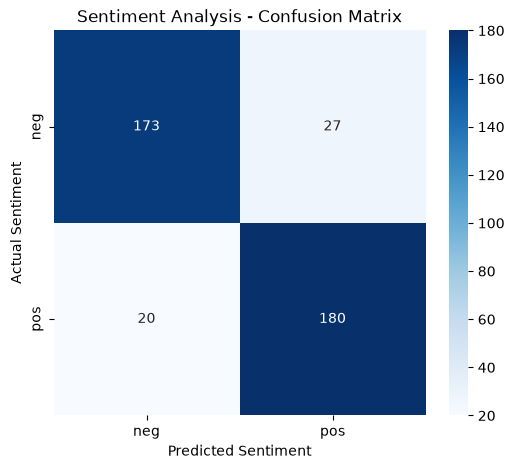

In [35]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test set evaluation
y_pred = classifier.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, 
                          target_names=classifier.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classifier.classes_,
            yticklabels=classifier.classes_)
plt.title('Sentiment Analysis - Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

Test Set Accuracy: 0.850 (85.0%)

Detailed Classification Report:
              precision    recall  f1-score   support

         neg       0.83      0.88      0.85       200
         pos       0.87      0.82      0.85       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400


Confusion Matrix:
[[175  25]
 [ 35 165]]


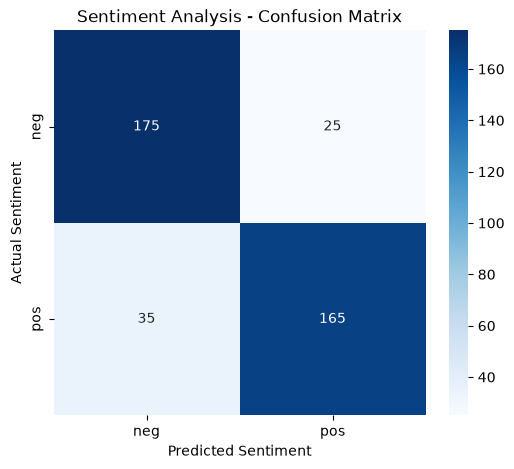

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test set evaluation
y_pred = classifier_tfidf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test Set Accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")

# Detailed classification report
print("\nDetailed Classification Report:")
print("=" * 50)
print(classification_report(y_test, y_pred, 
                          target_names=classifier_tfidf.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classifier_tfidf.classes_,
            yticklabels=classifier_tfidf.classes_)
plt.title('Sentiment Analysis - Confusion Matrix')
plt.ylabel('Actual Sentiment')
plt.xlabel('Predicted Sentiment')
plt.show()

### 8. Making Predictions
Testing the model with sample reviews from the test set

In [37]:
# Test with some examples from test set
sample_size = 5
sample_indices = np.random.choice(len(X_test_processed), sample_size, replace=False)

print("Sample Predictions from Test Set:")
print("=" * 60)

for i, idx in enumerate(sample_indices):
    # Get the processed text
    processed_text = X_test_processed[idx]
    
    # Transform to TF-IDF vector
    text_vector = tfidf_vectorizer.transform([processed_text])
    
    # Predict
    prediction = classifier.predict(text_vector)[0]
    probabilities = classifier.predict_proba(text_vector)[0]
    
    # Convert back to label names
    actual_label = y_test[idx]
    predicted_label = prediction
    
    print(f"\nSample {i+1}:")
    print(f"{X_test_text[idx][:200]}...")
    print(f"Actual: {actual_label.upper()}")
    print(f"Predicted: {predicted_label.upper()}")
    print(f"Confidence: Pos={probabilities[1]:.3f}, Neg={probabilities[0]:.3f}")
    print(f"Correct: {'✓' if actual_label == predicted_label else '✗'}")
    print("-" * 60)

Sample Predictions from Test Set:

Sample 1:
' bicentennial man ' is a family film without any external motive with the exception of providing the minimum dose of entertainment . chris columbus , the director who gave you " mrs . doubtfire " , p...
Actual: NEG
Predicted: POS
Confidence: Pos=0.632, Neg=0.368
Correct: ✗
------------------------------------------------------------

Sample 2:
i am a steven seagal fan . i only say this now because " mufti splenetik " isn ' t my real name and because i probably need to explain why i went into this film expecting great things . any proud seag...
Actual: NEG
Predicted: NEG
Confidence: Pos=0.307, Neg=0.693
Correct: ✓
------------------------------------------------------------

Sample 3:
some movies ask you to leave your brain at the door , some movies ask you to believe in the impossible to really have a good time . playing god asks just one simple , eensy , teensy thing so it can fu...
Actual: NEG
Predicted: NEG
Confidence: Pos=0.158, Neg=0.8